# Radioactive Decay Chain: Learning Branching Ratios

A 4-isotope radioactive decay chain A -> B -> C -> D (stable) where the decay constants are **known** but two **branching ratios** are unknown and learned from trajectory data.

**Known structure:**
```
A(n+1) = A(n) - lambda_A * A(n) * dt
B(n+1) = B(n) + lambda_A * f_branch * A(n) * dt - lambda_B * B(n) * dt
C(n+1) = C(n) + lambda_A * (1-f_branch) * A(n) * dt + lambda_B * g_branch * B(n) * dt - lambda_C * C(n) * dt
D(n+1) = D(n) + lambda_B * (1-g_branch) * B(n) * dt + lambda_C * C(n) * dt
```

**Known:** lambda_A=0.3, lambda_B=0.1, lambda_C=0.05, dt=0.5

**Unknown:** f_branch (true=0.7), g_branch (true=0.85) -- learned as sigmoid-constrained scalar parameters.

**Key invariant:** Total mass A + B + C + D is conserved (every term leaving one pool enters another).

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyBool, TyReal
from cajal.compiling import compile, TypedTensor

device = torch.device('cpu')

# Known parameters
LAMBDA_A = 0.3
LAMBDA_B = 0.1
LAMBDA_C = 0.05
DT = 0.5
A0, B0, C0, D0 = 1.0, 0.0, 0.0, 0.0
N_STEPS = 10

# Ground truth (hidden from learner)
TRUE_F_BRANCH = 0.7   # 70% of A decays go to B, 30% go to C
TRUE_G_BRANCH = 0.85  # 85% of B decays go to C, 15% go to D


def true_update(state):
    """Ground truth: one timestep of the decay chain."""
    a, b, c, d = state
    decay_a = LAMBDA_A * a * DT
    decay_b = LAMBDA_B * b * DT
    decay_c = LAMBDA_C * c * DT
    a_new = a - decay_a
    b_new = b + TRUE_F_BRANCH * decay_a - decay_b
    c_new = c + (1 - TRUE_F_BRANCH) * decay_a + TRUE_G_BRANCH * decay_b - decay_c
    d_new = d + (1 - TRUE_G_BRANCH) * decay_b + decay_c
    return torch.stack([a_new, b_new, c_new, d_new])


def generate_data():
    """Generate ground-truth trajectory."""
    states = []
    state = torch.tensor([A0, B0, C0, D0])
    for _ in range(N_STEPS):
        states.append(state.clone())
        state = true_update(state)
    return torch.stack(states)


data = generate_data()
print(f'Device: {device}')
print(f'Generated trajectory: {data.shape} (steps x isotopes)')
print(f'Initial mass: {data[0].sum().item():.4f}')
print(f'Final mass:   {data[-1].sum().item():.4f}')

Device: cpu
Generated trajectory: torch.Size([10, 4]) (steps x isotopes)
Initial mass: 1.0000
Final mass:   1.0000


In [2]:
class DecayChainUpdate(nn.Module):
    """One timestep of the 4-isotope decay chain with learnable branching ratios.
    
    Structure is FIXED by domain knowledge. Only f_branch and g_branch are
    learnable (sigmoid-constrained to [0,1]).
    """

    def __init__(self, lam_a, lam_b, lam_c, dt):
        super().__init__()
        self.lam_a, self.lam_b, self.lam_c, self.dt = lam_a, lam_b, lam_c, dt
        # Raw (pre-sigmoid) parameters, initialized at 0 (sigmoid(0)=0.5)
        self.f_branch_raw = nn.Parameter(torch.tensor(0.0))
        self.g_branch_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, state):
        a, b, c, d = state.data[0], state.data[1], state.data[2], state.data[3]
        f = torch.sigmoid(self.f_branch_raw)
        g = torch.sigmoid(self.g_branch_raw)

        decay_a = self.lam_a * a * self.dt
        decay_b = self.lam_b * b * self.dt
        decay_c = self.lam_c * c * self.dt

        a_new = a - decay_a
        b_new = b + f * decay_a - decay_b
        c_new = c + (1 - f) * decay_a + g * decay_b - decay_c
        d_new = d + (1 - g) * decay_b + decay_c

        return TypedTensor(torch.stack([a_new, b_new, c_new, d_new]), state.ty)


# Cajal program: iter{s0 | s -> f(s)}(n)
program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

update_fn = DecayChainUpdate(LAMBDA_A, LAMBDA_B, LAMBDA_C, DT)
optimizer = torch.optim.Adam(update_fn.parameters(), lr=0.05)

s0 = TypedTensor(torch.tensor([A0, B0, C0, D0]), TyReal(4))

f_init = torch.sigmoid(update_fn.f_branch_raw).item()
g_init = torch.sigmoid(update_fn.g_branch_raw).item()
print(f'Initial: f_branch={f_init:.4f} (true={TRUE_F_BRANCH}), g_branch={g_init:.4f} (true={TRUE_G_BRANCH})')

# Track history for plotting
losses = []
f_history = [f_init]
g_history = [g_init]

for epoch in range(400):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)

    for i in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS)
        n_onehot[i] = 1.0
        n_val = TypedTensor(n_onehot, TyNat())
        result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s), 'n': n_val})
        total_loss = total_loss + ((result.data - data[i]) ** 2).sum()

    total_loss.backward()
    optimizer.step()

    losses.append(total_loss.item())
    f_history.append(torch.sigmoid(update_fn.f_branch_raw).item())
    g_history.append(torch.sigmoid(update_fn.g_branch_raw).item())

    if epoch % 100 == 0 or epoch == 399:
        print(f'  epoch {epoch:3d}  loss={total_loss.item():.8f}  '
              f'f_branch={f_history[-1]:.4f}  g_branch={g_history[-1]:.4f}')

print('Training complete')

Initial: f_branch=0.5000 (true=0.7), g_branch=0.5000 (true=0.85)
  epoch   0  loss=0.13340217  f_branch=0.5125  g_branch=0.4875


  epoch 100  loss=0.00001079  f_branch=0.6987  g_branch=0.8373


  epoch 200  loss=0.00000002  f_branch=0.7000  g_branch=0.8494


  epoch 300  loss=0.00000000  f_branch=0.7000  g_branch=0.8500


  epoch 399  loss=0.00000000  f_branch=0.7000  g_branch=0.8500
Training complete


In [3]:
# Results
f_final = torch.sigmoid(update_fn.f_branch_raw).item()
g_final = torch.sigmoid(update_fn.g_branch_raw).item()

print('RESULTS')
print(f'  True f_branch:      {TRUE_F_BRANCH}')
print(f'  Recovered f_branch: {f_final:.4f}  (error={abs(f_final - TRUE_F_BRANCH):.6f})')
print(f'  True g_branch:      {TRUE_G_BRANCH}')
print(f'  Recovered g_branch: {g_final:.4f}  (error={abs(g_final - TRUE_G_BRANCH):.6f})')
print()
print('DECOMPILED SYSTEM:')
print(f'  dA/dt = -{LAMBDA_A} * A')
print(f'  dB/dt = {f_final:.4f} * {LAMBDA_A} * A - {LAMBDA_B} * B')
print(f'  dC/dt = {1-f_final:.4f} * {LAMBDA_A} * A + {g_final:.4f} * {LAMBDA_B} * B - {LAMBDA_C} * C')
print(f'  dD/dt = {1-g_final:.4f} * {LAMBDA_B} * B + {LAMBDA_C} * C')
print()
print(f'  {f_final*100:.1f}% of A decays produce B; {(1-f_final)*100:.1f}% produce C directly')
print(f'  {g_final*100:.1f}% of B decays produce C; {(1-g_final)*100:.1f}% produce D directly')

# Collect predicted trajectory for plotting
pred_traj = []
total_masses = []
with torch.no_grad():
    for i in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS)
        n_onehot[i] = 1.0
        n_val = TypedTensor(n_onehot, TyNat())
        result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s), 'n': n_val})
        vals = [result.data[j].item() for j in range(4)]
        pred_traj.append(vals)
        total_masses.append(sum(vals))

# Verification
all_positive = all(v >= -1e-10 for step in pred_traj for v in step)
initial_mass = A0 + B0 + C0 + D0
mass_conserved = all(abs(m - initial_mass) < 1e-4 for m in total_masses)

print()
print('VERIFICATION:')
print(f"  0 <= f_branch <= 1:  {'VERIFIED' if 0 <= f_final <= 1 else 'FAILED'} (sigmoid constraint)")
print(f"  0 <= g_branch <= 1:  {'VERIFIED' if 0 <= g_final <= 1 else 'FAILED'} (sigmoid constraint)")
print(f"  All pools >= 0:      {'VERIFIED' if all_positive else 'FAILED'}")
print(f"  Mass conservation:   {'VERIFIED' if mass_conserved else 'FAILED'} (A+B+C+D={initial_mass:.1f})")

RESULTS
  True f_branch:      0.7
  Recovered f_branch: 0.7000  (error=0.000000)
  True g_branch:      0.85
  Recovered g_branch: 0.8500  (error=0.000000)

DECOMPILED SYSTEM:
  dA/dt = -0.3 * A
  dB/dt = 0.7000 * 0.3 * A - 0.1 * B
  dC/dt = 0.3000 * 0.3 * A + 0.8500 * 0.1 * B - 0.05 * C
  dD/dt = 0.1500 * 0.1 * B + 0.05 * C

  70.0% of A decays produce B; 30.0% produce C directly
  85.0% of B decays produce C; 15.0% produce D directly

VERIFICATION:
  0 <= f_branch <= 1:  VERIFIED (sigmoid constraint)
  0 <= g_branch <= 1:  VERIFIED (sigmoid constraint)
  All pools >= 0:      VERIFIED
  Mass conservation:   VERIFIED (A+B+C+D=1.0)


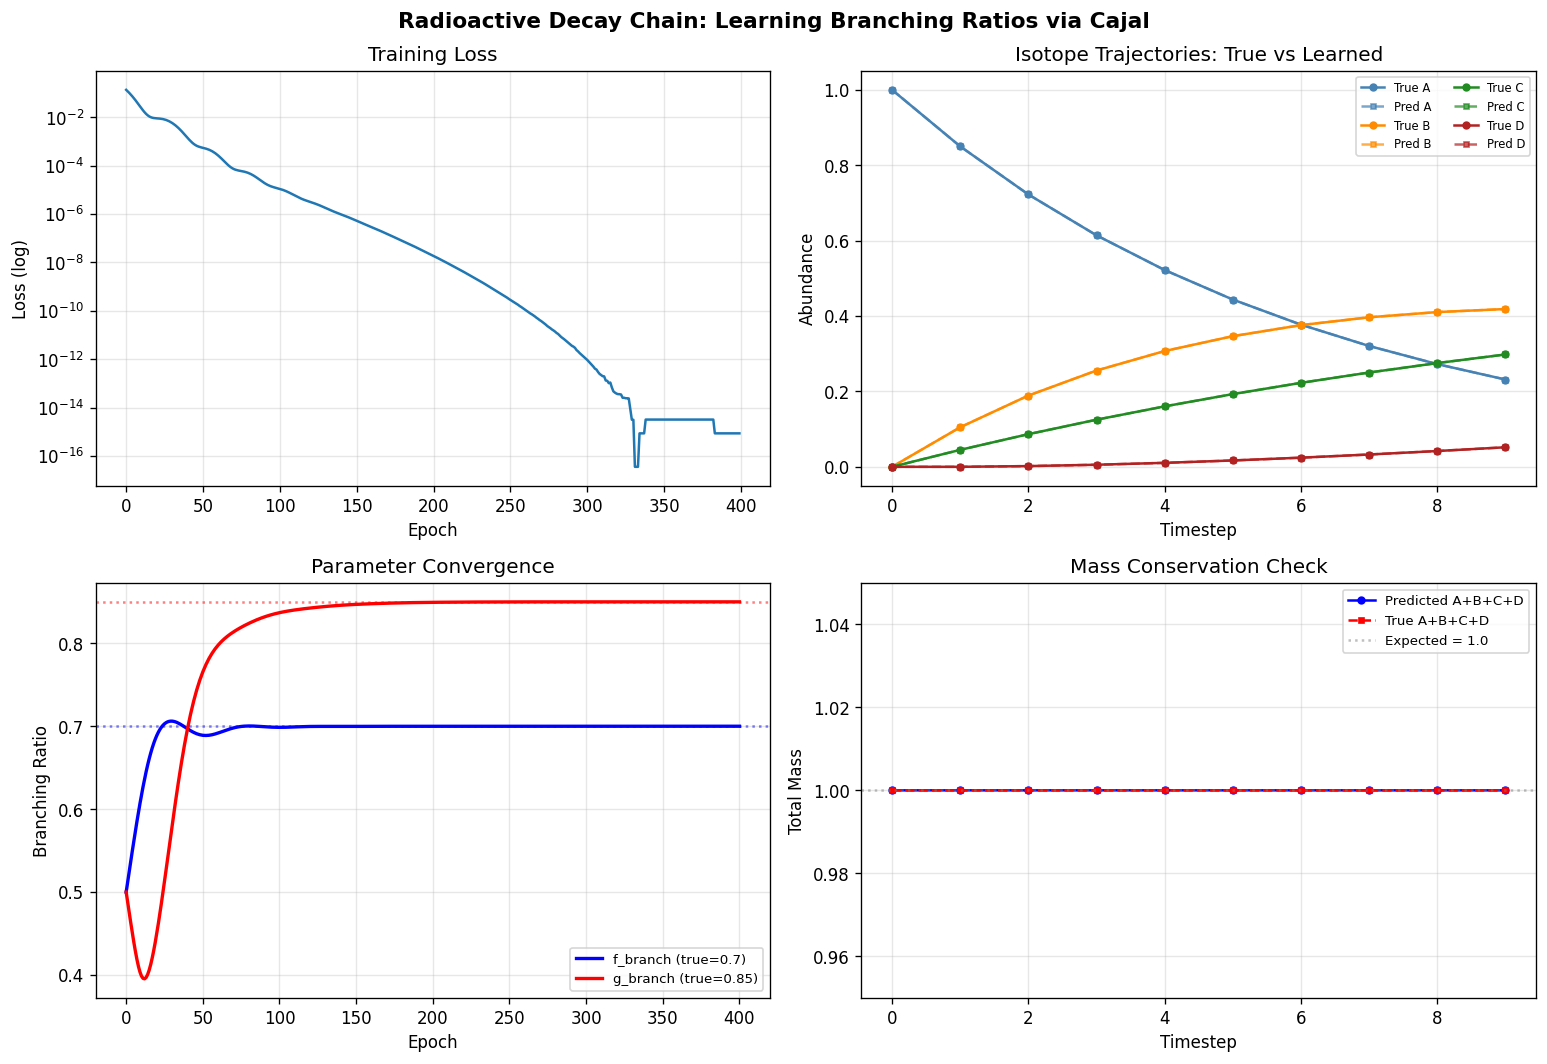

In [4]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Training loss
axes[0, 0].semilogy(losses)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log)')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# (2) All 4 isotope trajectories
steps = np.arange(N_STEPS)
true_np = data.numpy()
pred_np = np.array(pred_traj)
colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']
labels = ['A', 'B', 'C', 'D']
for j, (lbl, col) in enumerate(zip(labels, colors)):
    axes[0, 1].plot(steps, true_np[:, j], '-o', color=col, markersize=4, label=f'True {lbl}')
    axes[0, 1].plot(steps, pred_np[:, j], '--s', color=col, markersize=3, alpha=0.7, label=f'Pred {lbl}')
axes[0, 1].set_xlabel('Timestep')
axes[0, 1].set_ylabel('Abundance')
axes[0, 1].set_title('Isotope Trajectories: True vs Learned')
axes[0, 1].legend(ncol=2, fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# (3) Branching ratio convergence
epochs_ax = np.arange(len(f_history))
axes[1, 0].plot(epochs_ax, f_history, 'b-', lw=2, label=f'f_branch (true={TRUE_F_BRANCH})')
axes[1, 0].plot(epochs_ax, g_history, 'r-', lw=2, label=f'g_branch (true={TRUE_G_BRANCH})')
axes[1, 0].axhline(TRUE_F_BRANCH, color='b', ls=':', alpha=0.5)
axes[1, 0].axhline(TRUE_G_BRANCH, color='r', ls=':', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Branching Ratio')
axes[1, 0].set_title('Parameter Convergence')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# (4) Mass conservation check
true_masses = [data[i].sum().item() for i in range(N_STEPS)]
axes[1, 1].plot(steps, total_masses, 'b-o', markersize=4, label='Predicted A+B+C+D')
axes[1, 1].plot(steps, true_masses, 'r--s', markersize=3, label='True A+B+C+D')
axes[1, 1].axhline(initial_mass, color='gray', ls=':', alpha=0.5, label=f'Expected = {initial_mass:.1f}')
axes[1, 1].set_xlabel('Timestep')
axes[1, 1].set_ylabel('Total Mass')
axes[1, 1].set_title('Mass Conservation Check')
axes[1, 1].set_ylim(initial_mass - 0.05, initial_mass + 0.05)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Radioactive Decay Chain: Learning Branching Ratios via Cajal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decay_chain_results.png', dpi=120, bbox_inches='tight')
plt.show()